# NREL Cost Projections for Utility-Scale Battery Storage
Reports available for [2019](https://www.osti.gov/servlets/purl/1529218), [2020](https://www.nrel.gov/docs/fy20osti/75385.pdf), [2021](https://www.nrel.gov/docs/fy21osti/79236.pdf), [2023](https://www.nrel.gov/docs/fy23osti/85332.pdf).

They describe overnight capital costs for 4h duration utility-scale lithium-ion battery systems. These projections are used for NREL's Annual Technology Baseline and in NREL's capacity expansion models (e.g., ReEDS, RPM).

All costs are expressed in $2022 using the [consumer price index](https://www.rateinflation.com/consumer-price-index/usa-historical-cpi/).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [62]:
consumer_price_index = {2025: 319.082, 2022: 292.655, 2020: 258.811, 2019: 255.657, 2018: 251.107}
fpath = "../data/nrel_battery_cost/"
prediction_years = [2018, 2019, 2020, 2022]
reference_year = 2025
prediction_dict = {}
nrel = {}
for yr in prediction_years:
    prediction_dict[yr] = pd.read_csv(fpath+str(yr+1)+".txt", sep = ' ')
    nrel[yr] = pd.DataFrame({"year": prediction_dict[yr]["Year"],
                              "low": prediction_dict[yr]["Low.1"] * consumer_price_index[reference_year] / consumer_price_index[yr],
                              "mid": prediction_dict[yr]["Mid.1"] * consumer_price_index[reference_year] / consumer_price_index[yr],
                              "high": prediction_dict[yr]["High.1"] * consumer_price_index[reference_year] / consumer_price_index[yr],
                              })

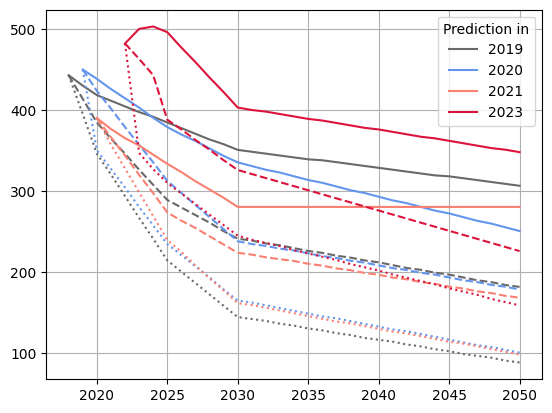

In [ ]:
color_list = ["dimgray", "cornflowerblue", "salmon", "crimson"]
for yr in prediction_years:
    # plt.fill_between(nrel[yr]["year"], nrel[yr]["low"], nrel[yr]["high"], label = yr+1, alpha = 1 - 0.75 * prediction_years.index(yr)/len(prediction_years))
    plt.plot(nrel[yr]["year"], nrel[yr]["low"], color = color_list[prediction_years.index(yr)], linestyle = "dotted")
    plt.plot(nrel[yr]["year"], nrel[yr]["mid"], color = color_list[prediction_years.index(yr)], linestyle = "dashed")
    plt.plot(nrel[yr]["year"], nrel[yr]["high"], color = color_list[prediction_years.index(yr)], linestyle = "solid", label = yr + 1)
plt.legend(title = "Prediction in")
plt.grid()

In [27]:
utility_projects = pd.DataFrame({"project": ["Nantucket", "Ponoma", "Provincetown"], "cost": 1000*np.array([72/48, 7.4/12, 54/38]), "year": [2019, 2020, 2022]})
for i in range(len(utility_projects)):
    utility_projects.loc[i, 'cost'] = utility_projects.iloc[i]["cost"] * consumer_price_index[reference_year] / consumer_price_index[utility_projects.iloc[i]["year"]]
utility_projects


,project,cost,year
0,Nantucket,1872.129455,2019
1,Ponoma,760.273842,2020
2,Provincetown,1549.374915,2022


In [30]:
# electric cars
# Nissan Leaf SV Plus 2025: https://www.caranddriver.com/nissan/leaf/specs/2025/nissan_leaf_nissan-leaf_2025/454225
# Chevy Bolt 2023: https://www.caranddriver.com/chevrolet/bolt-ev/specs/2023/chevrolet_bolt-ev_chevrolet-bolt-ev_2023/426900
# Model 3 Long Range RWD: https://www.caranddriver.com/tesla/model-3/specs/2025/tesla_model-3_tesla-model-3_2025/464774
cars = pd.DataFrame({"make": ["Leaf", "Bolt", "Model 3"], "cost": np.array([37330/60, 30695/66, 44130/82]), "year": [2025, 2025, 2025]})
for i in range(len(utility_projects)):
    cars.loc[i, 'cost'] = cars.iloc[i]["cost"] * consumer_price_index[reference_year] / consumer_price_index[cars.iloc[i]["year"]]
cars

,make,cost,year
0,Leaf,622.166667,2025
1,Bolt,465.075758,2025
2,Model 3,538.170732,2025


In [43]:
# multiple for distribution storage: current implementation works if there is a NREL forecast made in each year with distribution utility projects
dist_factor = 0
for i in utility_projects.index:
    dist_factor += utility_projects.cost[i] / nrel[utility_projects.year[i]]["mid"][0]
dist_factor = dist_factor/len(utility_projects)

In [64]:
# build most up to date NREL mid projection
nrel_updated = nrel[prediction_years[0]].copy(deep=True)
for yr in prediction_years:
    nrel_updated.iloc[-len(nrel[yr]):] = nrel[yr].values

In [65]:
# distribution battery price projection
dist = pd.DataFrame({"year": nrel_updated["year"], "cost": dist_factor * nrel_updated["mid"]})

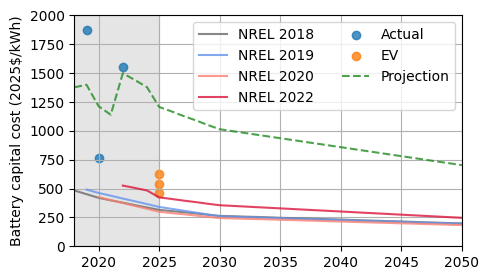

In [80]:
plt.figure(figsize=(5, 3))
color_list = ["dimgray", "cornflowerblue", "salmon", "crimson"]
# gray past
plt.axvspan(xmin=2018, xmax=2025, color='gray', alpha=0.2)  # Vertical gray box
# NREL predictions
for yr in prediction_years:
    # plt.fill_between(nrel[yr]["year"], nrel[yr]["low"], nrel[yr]["high"], label = yr+1, alpha = 1 - 0.75 * prediction_years.index(yr)/len(prediction_years))
    # plt.plot(nrel[yr]["year"], nrel[yr]["low"], color = color_list[prediction_years.index(yr)], linestyle = "dotted")
    plt.plot(nrel[yr]["year"], nrel[yr]["mid"], color = color_list[prediction_years.index(yr)], linestyle = "solid", label = "NREL " + str(yr), alpha = 0.8)
    # plt.plot(nrel[yr]["year"], nrel[yr]["high"], color = color_list[prediction_years.index(yr)], linestyle = "solid", label = yr + 1)
# NE distribution batteries
plt.scatter(utility_projects.year, utility_projects.cost, label = 'Actual', alpha = 0.8)
# EV
plt.scatter(cars.year, cars.cost, label = 'EV', alpha = 0.8)
# Distribution battery cost projection
plt.plot(dist.year, dist.cost, linestyle = "dashed", color = "forestgreen", label = "Projection", alpha = 0.8)
# Formatting
plt.legend(ncols = 2)
plt.axis([2018, 2050, 0, 2000])
plt.ylabel("Battery capital cost (2025$/kWh)")
plt.grid()
plt.savefig('../pics/battery_cost.svg', format='svg', bbox_inches = 'tight')
plt.savefig('../pics/battery_cost.pdf', format='pdf', bbox_inches = 'tight')